# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [5]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier
# pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

def check_plot(df, variable):
    # fungsi mengambil kerangka data (df) dan
    # variabel yang diminati sebagai argumen

    # tentukan ukuran gambar
    plt.figure(figsize=(16, 4))

    # Histogram
    plt.subplot(1, 3, 1)
    sns.histplot(df[variable], bins=30)
    plt.title(f'Histogram {variable}')

    # Q-Q Plot
    plt.subplot(1, 3, 2)
    stats.probplot(df[variable], dist="norm", plot=plt)
    plt.title(f'Q-Q Plot {variable}')

    # Boxplot
    plt.subplot(1, 3, 3)
    sns.boxplot(y=df[variable])
    plt.title(f'Boxplot {variable}')

    plt.show()


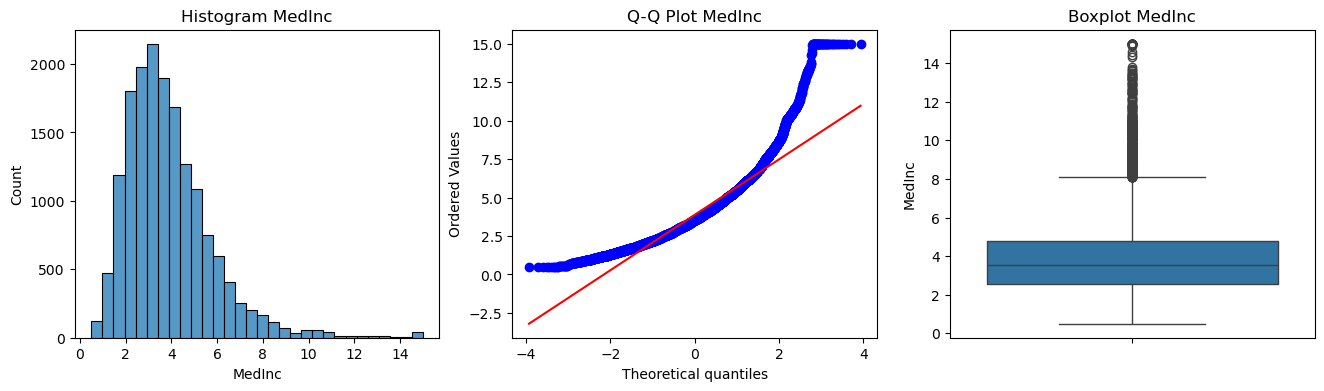

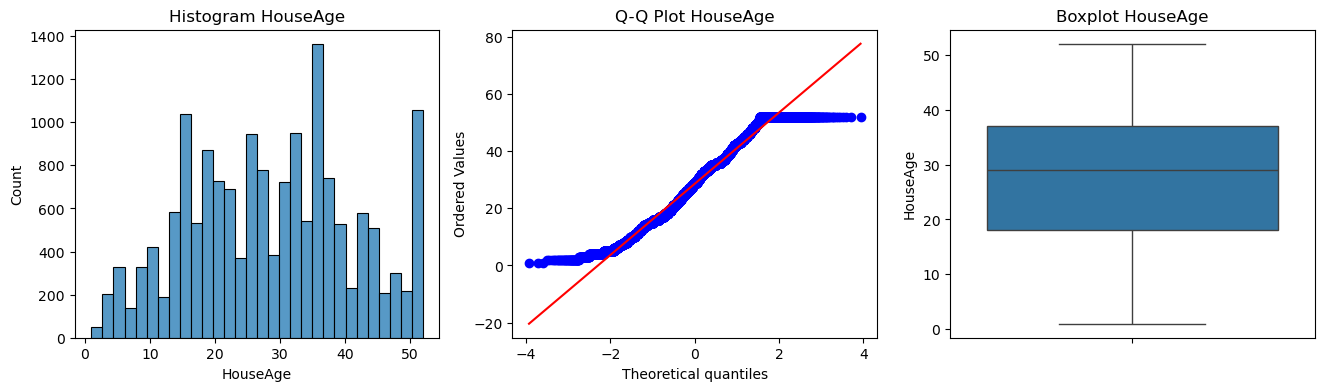

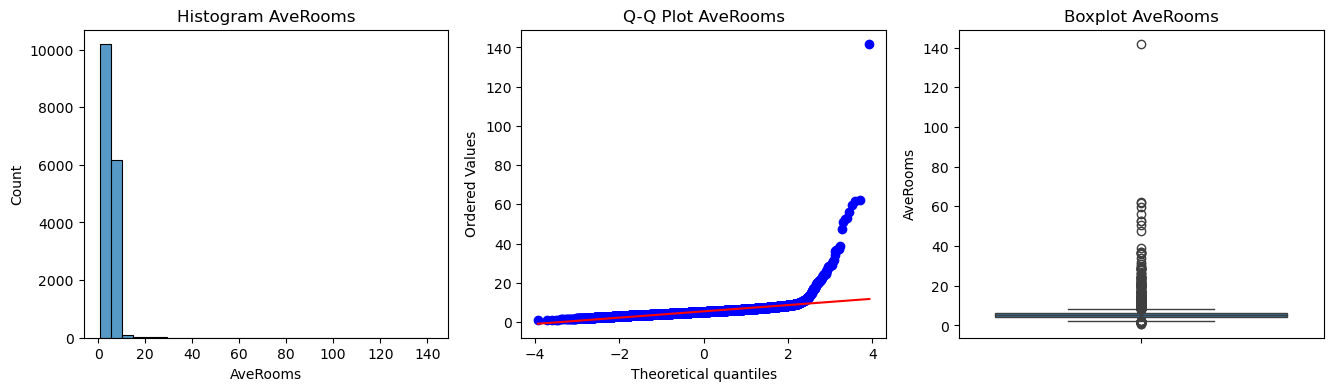

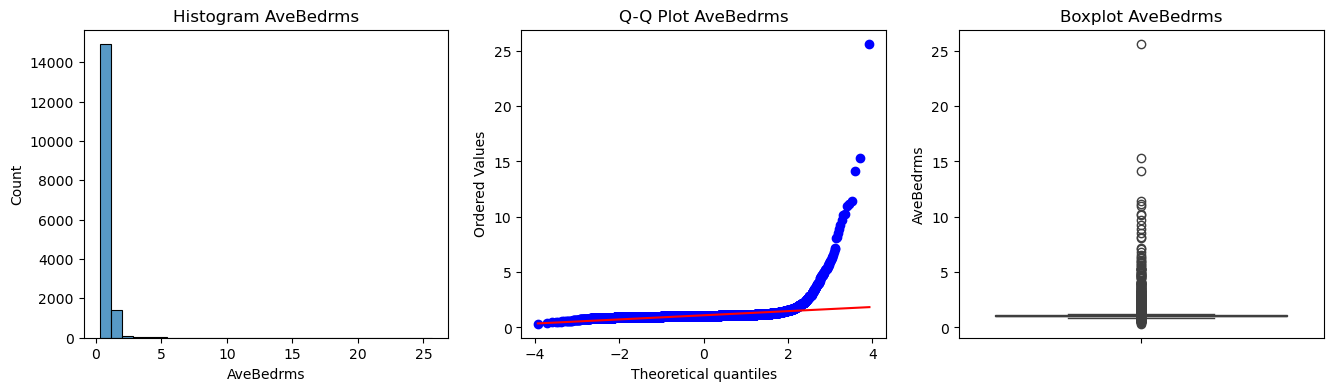

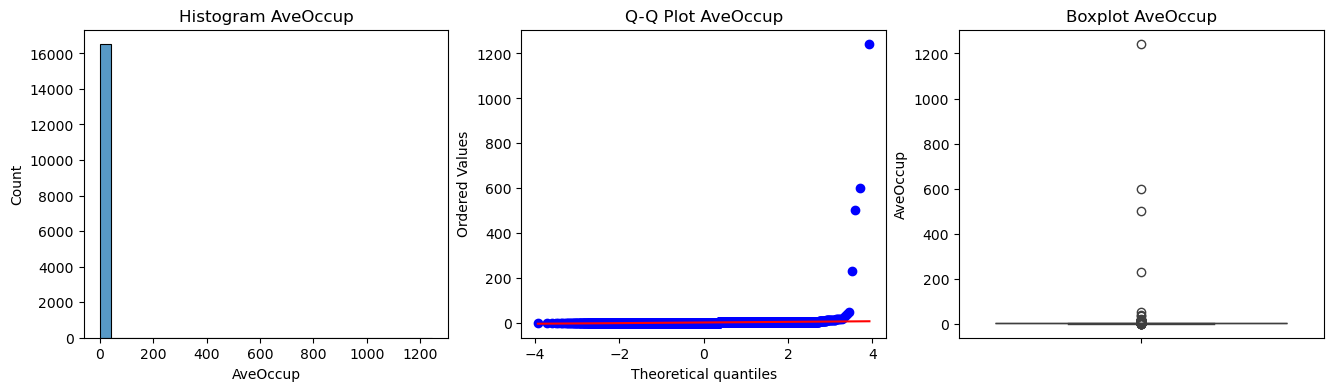

In [6]:
# Looping untuk melihat distribusi dan outlier tiap kolom
for kolom in kolom_kolom:
    check_plot(train_clfr, kolom)


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

In [7]:
def find_outlier_boundary(df, variable):

    # Mari kita hitung batas luar yang merupakan outlier

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)

    return upper_boundary, lower_boundary

In [8]:
HouseAge_upper_limit, HouseAge_lower_limit = find_outlier_boundary(train_clfr, 'HouseAge')

HouseAge_upper_limit, HouseAge_lower_limit

(np.float64(65.5), np.float64(-10.5))

In [9]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
import numpy as np

train_clfr['HouseAge'] = np.where(
    train_clfr['HouseAge'] > HouseAge_upper_limit,
    HouseAge_upper_limit,
    np.where(
        train_clfr['HouseAge'] < HouseAge_lower_limit,
        HouseAge_lower_limit,
        train_clfr['HouseAge']
    )
)

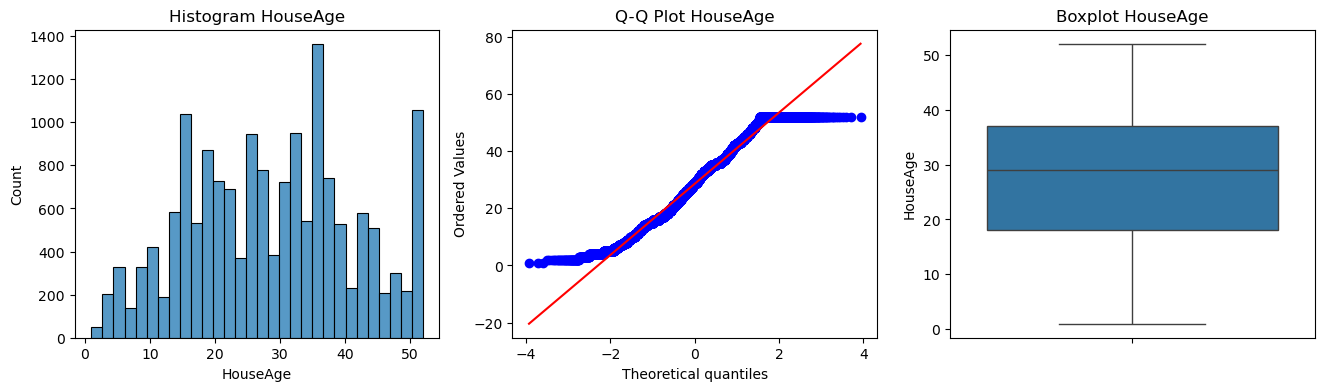

In [10]:
# Melakukan loop untuk mengecek distribusi tiap kolom
check_plot(train_clfr, 'HouseAge')

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [11]:
df_company = pd.read_csv('company.csv')

In [12]:
from feature_engine.outliers import ArbitraryOutlierCapper

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [13]:
df_company.head()


,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


In [14]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [15]:
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print()

============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 3.3    41
 4.0    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.4    31
 3.6    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 4.3    14
 2.9    14
 3.1    12
 4.6    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.3     1
 2.4     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY                 33
San Francisco, CA            31
-1                           31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Washington, DC                7
Saint Louis, MO               7
Denver, CO                    7
Arlington, VA                 7
Bedford, MA                   7
Woodbine, MD                  7
San Jose, CA                  7
San Rafael, CA                6
Basel, Switzerland            6
Chantilly, VA                 6
San Antonio, TX               6
Mountain View, CA             6
Princeton, NJ                 5
Fairfax, VA                   5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Springfield, MA               5
Los Angeles, CA            

In [16]:
# Tulis jawaban missing value handling kolom Headquarters disini
# Cek jenis missing value pada kolom Headquarters
print('Value counts kolom Headquarters:')
print(df_company['Headquarters'].value_counts(dropna=False))
print()

# Hitung persentase missing value (nilai -1 atau NaN dianggap missing)
pct_missing_hq = 100 * df_company['Headquarters'].isnull().sum() / len(df_company)
print(f'Persentase NaN di Headquarters: {pct_missing_hq:.2f}%')

# Cek juga nilai tidak wajar lain seperti '-1'
pct_invalid_hq = 100 * len(df_company[df_company['Headquarters'] == '-1']) / len(df_company)
print(f'Persentase nilai -1 di Headquarters: {pct_invalid_hq:.2f}%')


Value counts kolom Headquarters:
Headquarters
New York, NY                 33
San Francisco, CA            31
-1                           31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Washington, DC                7
Saint Louis, MO               7
Denver, CO                    7
Arlington, VA                 7
Bedford, MA                   7
Woodbine, MD                  7
San Jose, CA                  7
San Rafael, CA                6
Basel, Switzerland            6
Chantilly, VA                 6
San Antonio, TX               6
Mountain View, CA             6
Princeton, NJ                 5
Fairfax, VA                   5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Springfield, MA           

In [17]:
# Total persentase missing value (NaN + nilai tidak wajar '-1') di Headquarters
pct_nan = 100 * df_company['Headquarters'].isnull().sum() / len(df_company)
pct_invalid = 100 * len(df_company[df_company['Headquarters'] == '-1']) / len(df_company)
total_missing_hq = pct_nan + pct_invalid
print(f'Total persentase missing value di Headquarters: {total_missing_hq:.2f}%')

# Aturan: jika > 20% maka DROP kolom, jika <= 20% maka HANDLING
if total_missing_hq > 20:
    print('=> Kolom Headquarters DIDROP karena missing value > 20%')
else:
    print('=> Kolom Headquarters TIDAK DIDROP, perlu di-handling karena missing value <= 20%')


Total persentase missing value di Headquarters: 4.61%
=> Kolom Headquarters TIDAK DIDROP, perlu di-handling karena missing value <= 20%


In [18]:
# Cek persentase missing value kolom Size
pct_size = 100 * len(df_company[df_company['Size'].isin(['-1', 'Unknown'])]) / len(df_company)
print(f'Persentase missing value di Size: {pct_size:.2f}%')


Persentase missing value di Size: 6.55%


In [19]:
# Cek persentase missing value kolom Revenue
pct_revenue = 100 * len(df_company[df_company['Revenue'].isin(['-1', 'Unknown / Non-Applicable'])]) / len(df_company)
print(f'Persentase missing value di Revenue: {pct_revenue:.2f}%')


Persentase missing value di Revenue: 35.71%


In [20]:
# Karena Revenue > 20% missing value, maka kolom Revenue didrop
df_company = df_company.drop(columns=['Revenue'])
df_company.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Size          672 non-null    object 
 1   Rating        672 non-null    float64
 2   Headquarters  672 non-null    object 
dtypes: float64(1), object(2)
memory usage: 15.9+ KB


In [21]:
from sklearn.model_selection import train_test_split
train_company, test_company = train_test_split(df_company, test_size=0.2, random_state=42)


In [22]:
# Kolom Headquarters adalah tipe kategorik/object => handling dengan MODUS

# Ganti nilai '-1' dengan NaN terlebih dahulu agar bisa di-handle
import numpy as np
train_company['Headquarters'] = train_company['Headquarters'].replace('-1', np.nan)
test_company['Headquarters'] = test_company['Headquarters'].replace('-1', np.nan)

# Cek jumlah missing
print('Missing value Headquarters (train):', train_company['Headquarters'].isnull().sum())

# Ambil modus dari data train
mode_headquarters = train_company['Headquarters'].mode()[0]
print(f'Modus Headquarters: {mode_headquarters}')

# Imputasi dengan modus (fit dari train, terapkan ke train dan test)
train_company['Headquarters'] = train_company['Headquarters'].fillna(mode_headquarters)
test_company['Headquarters'] = test_company['Headquarters'].fillna(mode_headquarters)

# Validasi
print('Missing value setelah imputasi (train):', train_company['Headquarters'].isnull().sum())
print('Missing value setelah imputasi (test):', test_company['Headquarters'].isnull().sum())


Missing value Headquarters (train): 24
Modus Headquarters: New York, NY
Missing value setelah imputasi (train): 0
Missing value setelah imputasi (test): 0


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [24]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [25]:
# Splitting terlebih dahulu
from sklearn.model_selection import train_test_split
train_churn, test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [26]:
# Assignment 3.a Label Encoder
from sklearn.preprocessing import LabelEncoder

# 1. Pilih kolom-kolom yang akan di-encoding
columns_label = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection',
                  'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# 2. Ganti nilai yang tidak sesuai:
#    'No internet service' -> 'No' (untuk semua kecuali MultipleLines)
#    'No phone service' -> 'No' (untuk MultipleLines)
internet_service_cols = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection',
                          'OnlineBackup', 'OnlineSecurity']

for col in internet_service_cols:
    train_churn[col] = train_churn[col].replace({'No internet service': 'No'})
    test_churn[col] = test_churn[col].replace({'No internet service': 'No'})

train_churn['MultipleLines'] = train_churn['MultipleLines'].replace({'No phone service': 'No'})
test_churn['MultipleLines'] = test_churn['MultipleLines'].replace({'No phone service': 'No'})


In [27]:
# Validasi dengan value_counts setelah penggantian nilai
for col in columns_label:
    print(f'=== {col} ===')
    print(train_churn[col].value_counts())
    print()


=== StreamingMovies ===
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64

=== StreamingTV ===
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

=== TechSupport ===
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

=== DeviceProtection ===
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

=== OnlineBackup ===
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

=== OnlineSecurity ===
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

=== MultipleLines ===
MultipleLines
No     3237
Yes    2397
Name: count, dtype: int64



In [28]:
# 3. Lakukan Label Encoding
label_encoder = LabelEncoder()

# fit di data train, transform ke train dan test (untuk mencegah data leakage)
for col in columns_label:
    train_churn[col] = label_encoder.fit_transform(train_churn[col])
    test_churn[col] = label_encoder.transform(test_churn[col])

print('Label Encoding selesai!')
train_churn[columns_label].head()


Label Encoding selesai!


,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1


In [29]:
# Cek hasil Label Encoding
print('=== train_churn ===')
print(train_churn[columns_label].value_counts().head(10))
print()
print('Sample data train setelah encoding:')
train_churn[columns_label].head()


=== train_churn ===
StreamingMovies  StreamingTV  TechSupport  DeviceProtection  OnlineBackup  OnlineSecurity  MultipleLines
0                0            0            0                 0             0               0                1327
                                                                                           1                 441
1                1            1            1                 1             1               1                 170
                              0            1                 1             0               1                 121
0                0            0            0                 1             0               0                 108
                 1            0            0                 0             0               0                  95
                 0            0            0                 0             1               0                  93
1                1            0            1                 0             0        

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1


## Selesai :)